
# Binary Stress Model — NORMAL vs HIGH

This notebook converts the previous 3-class stress problem into a binary problem:

- `LOW + MODERATE -> NORMAL (0)`
- `HIGH -> HIGH (1)`

The pipeline keeps the strict subject-wise train / validation / test split, so the final test still measures generalization to unseen subjects.

Pipeline:

1. Mount Google Drive and load `stress_dataset_colab.zip`
2. Extract the original 35 NPZ subject files
3. Generate physiology-preserving 30-second EEG + GSR image pairs
4. Convert labels to binary NORMAL / HIGH
5. Train a binary dual-CNN model with squeeze-excitation and gated fusion
6. Tune the decision threshold on validation data
7. Evaluate on the untouched unseen-subject test set
8. Export Keras + TFLite

> 80%+ unseen-subject accuracy is a target, not a guarantee. The notebook does not introduce subject leakage just to inflate the score.


In [3]:

# ============================================================
# 1. LOAD DATASET ZIP FROM GOOGLE DRIVE
# ============================================================

import os
import zipfile
import shutil
from pathlib import Path
from google.colab import drive

print("=" * 72)
print("MOUNT GOOGLE DRIVE")
print("=" * 72)

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
ZIP_NAME = "stress_dataset_colab.zip"

matches = list(DRIVE_ROOT.rglob(ZIP_NAME))

if len(matches) == 0:
    raise FileNotFoundError(
        f"{ZIP_NAME} was not found anywhere inside MyDrive."
    )

if len(matches) > 1:
    print("\nMultiple matching ZIPs found:")
    for i, p in enumerate(matches, start=1):
        print(f"{i}. {p}")
    print("\nUsing the first match.")

DRIVE_ZIP_PATH = matches[0]

print("\nDataset ZIP:")
print(DRIVE_ZIP_PATH)
print("Size MB:", round(DRIVE_ZIP_PATH.stat().st_size / 1024**2, 2))
print("Valid ZIP:", zipfile.is_zipfile(DRIVE_ZIP_PATH))

if not zipfile.is_zipfile(DRIVE_ZIP_PATH):
    raise RuntimeError("The Drive file is not a valid ZIP.")

DATASET_DIR = Path("/content/stress_dataset")
MANIFEST_PATH = DATASET_DIR / "window_manifest.csv"
WINDOW_DIR = DATASET_DIR / "windows"

ready = (
    MANIFEST_PATH.exists()
    and WINDOW_DIR.exists()
    and len(list(WINDOW_DIR.glob("*.npz"))) == 35
)

if not ready:
    if DATASET_DIR.exists():
        shutil.rmtree(DATASET_DIR)

    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    print("\nExtracting dataset...")

    with zipfile.ZipFile(DRIVE_ZIP_PATH, "r") as z:
        bad = z.testzip()
        if bad is not None:
            raise RuntimeError(f"Corrupted ZIP entry: {bad}")
        z.extractall(DATASET_DIR)

print("\nManifest exists:", MANIFEST_PATH.exists())
print("NPZ files:", len(list(WINDOW_DIR.glob("*.npz"))))

assert MANIFEST_PATH.exists()
assert len(list(WINDOW_DIR.glob("*.npz"))) == 35

print("\nORIGINAL DATASET READY ✅")


MOUNT GOOGLE DRIVE
Mounted at /content/drive

Dataset ZIP:
/content/drive/MyDrive/stress_dataset_colab.zip
Size MB: 451.77
Valid ZIP: True

Extracting dataset...

Manifest exists: True
NPZ files: 35

ORIGINAL DATASET READY ✅


In [4]:

# ============================================================
# 2. GENERATE 30-SECOND PHYSIOLOGY-PRESERVING V3 IMAGES
# ============================================================

import os
import gc
import numpy as np
import pandas as pd

from pathlib import Path
from scipy.signal import spectrogram, savgol_filter
from PIL import Image, ImageDraw

DATASET_ROOT = Path("/content/stress_dataset")
WINDOW_DIR = DATASET_ROOT / "windows"
MANIFEST_PATH = DATASET_ROOT / "window_manifest.csv"

OUT_ROOT = Path("/content/stress_image_dataset_binary")
EEG_DIR = OUT_ROOT / "eeg"
GSR_DIR = OUT_ROOT / "gsr"
V3_MANIFEST = OUT_ROOT / "image_manifest_binary.csv"

EEG_DIR.mkdir(parents=True, exist_ok=True)
GSR_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
EEG_FS = 128
SEGMENT_WINDOWS = 6     # 6 x 5 sec = 30 sec
SEGMENT_STRIDE = 2      # 10 sec step

base_manifest = pd.read_csv(MANIFEST_PATH)

print("=" * 76)
print("30-SECOND EEG + GSR IMAGE GENERATION")
print("=" * 76)
print("Subjects:", base_manifest["subject"].nunique())
print("Original windows:", len(base_manifest))

def decode_phase(x):
    if isinstance(x, bytes):
        return x.decode("utf-8")
    return str(x)

def robust_uint8(x, lo=None, hi=None):
    x = np.asarray(x, dtype=np.float32)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    if lo is None:
        lo = np.percentile(x, 2)
    if hi is None:
        hi = np.percentile(x, 98)

    if hi <= lo:
        hi = lo + 1e-6

    x = np.clip((x - lo) / (hi - lo), 0, 1)
    return (x * 255).astype(np.uint8)

def eeg_band_image(eeg_30s):
    bands = [(4, 8), (8, 13), (13, 30)]
    channel_features = []

    for ch in range(eeg_30s.shape[0]):
        f, t, sxx = spectrogram(
            eeg_30s[ch],
            fs=EEG_FS,
            nperseg=256,
            noverlap=192,
            nfft=256,
            scaling="density",
            mode="psd",
        )

        band_series = []

        for low, high in bands:
            mask = (f >= low) & (f < high)
            power = np.mean(sxx[mask], axis=0)
            power = 10.0 * np.log10(power + 1e-12)
            band_series.append(power.astype(np.float32))

        channel_features.append(
            np.stack(band_series, axis=-1)
        )

    feat = np.stack(channel_features, axis=0)

    rgb = np.zeros_like(feat, dtype=np.uint8)

    for b in range(3):
        rgb[..., b] = robust_uint8(feat[..., b])

    image = Image.fromarray(rgb)
    image = image.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BICUBIC
    )

    return image

def smooth_gsr(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) >= 11:
        return savgol_filter(
            x,
            11,
            2,
            mode="interp"
        ).astype(np.float32)

    return x.copy()

def draw_signal_channel(signal, lo, hi):
    signal = np.asarray(signal, dtype=np.float32)
    signal = np.nan_to_num(
        signal,
        nan=0.0,
        posinf=hi,
        neginf=lo
    )

    if hi <= lo:
        hi = lo + 1e-6

    y = np.clip(
        (signal - lo) / (hi - lo),
        0,
        1
    )

    xs = np.linspace(
        0,
        IMAGE_SIZE - 1,
        len(y)
    )

    ys = (
        1.0 - y
    ) * (
        IMAGE_SIZE - 1
    )

    canvas = Image.new(
        "L",
        (IMAGE_SIZE, IMAGE_SIZE),
        0
    )

    draw = ImageDraw.Draw(canvas)

    points = [
        (float(xs[i]), float(ys[i]))
        for i in range(len(y))
    ]

    if len(points) >= 2:
        draw.line(
            points,
            fill=255,
            width=3
        )

    return np.asarray(
        canvas,
        dtype=np.uint8
    )

def gsr_three_channel_image(gsr_30s, scale):
    raw = np.asarray(
        gsr_30s,
        dtype=np.float32
    )

    tonic = smooth_gsr(raw)
    phasic = raw - tonic
    derivative = np.gradient(raw).astype(np.float32)

    r = draw_signal_channel(
        raw,
        scale["raw_lo"],
        scale["raw_hi"]
    )

    g = draw_signal_channel(
        phasic,
        scale["phasic_lo"],
        scale["phasic_hi"]
    )

    b = draw_signal_channel(
        derivative,
        scale["deriv_lo"],
        scale["deriv_hi"]
    )

    rgb = np.stack(
        [r, g, b],
        axis=-1
    )

    return Image.fromarray(rgb)

def build_segments(npz_file):
    data = np.load(
        npz_file,
        mmap_mode="r"
    )

    labels = np.asarray(
        data["labels"]
    ).astype(np.int32)

    phases = np.asarray([
        decode_phase(x)
        for x in data["phases"]
    ])

    window_indices = np.asarray(
        data["window_indices"]
    ).astype(np.int32)

    segments = []

    for phase in np.unique(phases):
        idx = np.where(
            phases == phase
        )[0]

        idx = idx[
            np.argsort(
                window_indices[idx]
            )
        ]

        for start in range(
            0,
            len(idx) - SEGMENT_WINDOWS + 1,
            SEGMENT_STRIDE
        ):
            sel = idx[
                start:
                start + SEGMENT_WINDOWS
            ]

            wis = window_indices[sel]

            if not np.all(
                np.diff(wis) == 1
            ):
                continue

            labs = labels[sel]

            if not np.all(
                labs == labs[0]
            ):
                continue

            segments.append({
                "phase": phase,
                "start_window": int(wis[0]),
                "indices": sel,
                "original_label_id": int(labs[0]),
            })

    data.close()

    return segments

# ------------------------------------------------------------
# TRAIN-ONLY GSR SCALING
# ------------------------------------------------------------

train_subjects = set(
    base_manifest.loc[
        base_manifest["split"] == "train",
        "subject"
    ].astype(str).unique()
)

raw_vals = []
phasic_vals = []
deriv_vals = []

print("\nComputing train-only GSR scaling...")

for npz_file in sorted(
    WINDOW_DIR.glob("*.npz")
):
    subject = npz_file.stem

    if subject not in train_subjects:
        continue

    data = np.load(
        npz_file,
        mmap_mode="r"
    )

    eda = data["eda"]

    for i in range(
        0,
        len(eda),
        10
    ):
        x = np.asarray(
            eda[i],
            dtype=np.float32
        )

        tonic = smooth_gsr(x)

        raw_vals.append(x)
        phasic_vals.append(
            x - tonic
        )
        deriv_vals.append(
            np.gradient(x).astype(np.float32)
        )

    data.close()

raw_vals = np.concatenate(raw_vals)
phasic_vals = np.concatenate(phasic_vals)
deriv_vals = np.concatenate(deriv_vals)

GSR_SCALE = {
    "raw_lo":
        float(np.percentile(raw_vals, 1)),

    "raw_hi":
        float(np.percentile(raw_vals, 99)),

    "phasic_lo":
        float(np.percentile(phasic_vals, 1)),

    "phasic_hi":
        float(np.percentile(phasic_vals, 99)),

    "deriv_lo":
        float(np.percentile(deriv_vals, 1)),

    "deriv_hi":
        float(np.percentile(deriv_vals, 99)),
}

print("GSR scale:", GSR_SCALE)

del raw_vals
del phasic_vals
del deriv_vals

gc.collect()

# ------------------------------------------------------------
# GENERATION
# ------------------------------------------------------------

records = []

npz_files = sorted(
    WINDOW_DIR.glob("*.npz")
)

for sidx, npz_file in enumerate(
    npz_files,
    start=1
):
    subject = npz_file.stem

    subject_rows = base_manifest[
        base_manifest["subject"].astype(str)
        == subject
    ]

    if len(subject_rows) == 0:
        continue

    split = str(
        subject_rows["split"].iloc[0]
    )

    eeg_subdir = EEG_DIR / subject
    gsr_subdir = GSR_DIR / subject

    eeg_subdir.mkdir(
        parents=True,
        exist_ok=True
    )

    gsr_subdir.mkdir(
        parents=True,
        exist_ok=True
    )

    data = np.load(
        npz_file,
        mmap_mode="r"
    )

    eeg = data["eeg"]
    eda = data["eda"]

    segments = build_segments(
        npz_file
    )

    new_count = 0

    for seg in segments:
        phase = seg["phase"]
        start_w = seg["start_window"]
        original_label_id = seg[
            "original_label_id"
        ]
        sel = seg["indices"]

        # Original:
        # 0 = low
        # 1 = moderate
        # 2 = high
        #
        # Binary:
        # low + moderate -> normal (0)
        # high -> high (1)
        binary_label_id = (
            1
            if original_label_id == 2
            else 0
        )

        binary_label = (
            "high"
            if binary_label_id == 1
            else "normal"
        )

        stem = (
            f"{subject}_{phase}_"
            f"s{start_w:03d}"
        )

        eeg_path = (
            eeg_subdir
            /
            f"{stem}.png"
        )

        gsr_path = (
            gsr_subdir
            /
            f"{stem}.png"
        )

        if not (
            eeg_path.exists()
            and
            gsr_path.exists()
        ):
            eeg_30s = np.concatenate(
                [
                    np.asarray(
                        eeg[i],
                        dtype=np.float32
                    )
                    for i in sel
                ],
                axis=1
            )

            gsr_30s = np.concatenate(
                [
                    np.asarray(
                        eda[i],
                        dtype=np.float32
                    )
                    for i in sel
                ],
                axis=0
            )

            eeg_img = eeg_band_image(
                eeg_30s
            )

            gsr_img = gsr_three_channel_image(
                gsr_30s,
                GSR_SCALE
            )

            eeg_img.save(
                eeg_path,
                format="PNG",
                optimize=True
            )

            gsr_img.save(
                gsr_path,
                format="PNG",
                optimize=True
            )

            new_count += 1

        records.append({
            "subject": subject,
            "phase": phase,
            "start_window": start_w,
            "original_label_id":
                original_label_id,
            "binary_label_id":
                binary_label_id,
            "binary_label":
                binary_label,
            "split":
                split,
            "eeg_image":
                str(eeg_path),
            "gsr_image":
                str(gsr_path),
        })

    data.close()
    gc.collect()

    print(
        f"[{sidx:02d}/{len(npz_files)}] "
        f"{subject}: "
        f"segments={len(segments)}, "
        f"new={new_count}"
    )

binary_df = pd.DataFrame(
    records
)

binary_df.to_csv(
    V3_MANIFEST,
    index=False
)

print("\n" + "=" * 76)
print("BINARY IMAGE DATASET COMPLETE")
print("=" * 76)

print("Segments:", len(binary_df))
print("Subjects:", binary_df["subject"].nunique())

print("\nBinary classes:")
print(
    binary_df[
        "binary_label"
    ].value_counts()
)

print("\nSplits:")
print(
    binary_df[
        "split"
    ].value_counts()
)

# Verification
assert (
    binary_df
    .groupby("subject")["split"]
    .nunique()
    .max()
    == 1
)

assert binary_df[
    "eeg_image"
].map(os.path.exists).all()

assert binary_df[
    "gsr_image"
].map(os.path.exists).all()

print("\nNO SUBJECT LEAKAGE ✅")
print("BINARY DATASET READY ✅")


30-SECOND EEG + GSR IMAGE GENERATION
Subjects: 35
Original windows: 12451

Computing train-only GSR scaling...
GSR scale: {'raw_lo': 0.10078026354312897, 'raw_hi': 6.013220310211182, 'phasic_lo': -0.010921626351773739, 'phasic_hi': 0.010950040072202682, 'deriv_lo': -0.018200913444161415, 'deriv_hi': 0.024940919131040573}
[01/35] p01: segments=167, new=167
[02/35] p02: segments=170, new=170
[03/35] p03: segments=170, new=170
[04/35] p04: segments=170, new=170
[05/35] p05: segments=170, new=170
[06/35] p06: segments=170, new=170
[07/35] p07: segments=170, new=170
[08/35] p08: segments=170, new=170
[09/35] p09: segments=170, new=170
[10/35] p10: segments=170, new=170
[11/35] p11: segments=170, new=170
[12/35] p12: segments=170, new=170
[13/35] p13: segments=170, new=170
[14/35] p15: segments=170, new=170
[15/35] p16: segments=102, new=102
[16/35] p17: segments=170, new=170
[17/35] p18: segments=170, new=170
[18/35] p19: segments=170, new=170
[19/35] p20: segments=170, new=170
[20/35] p21:

In [5]:

# ============================================================
# 3. BINARY DATASET VERIFICATION
# ============================================================

import os
import pandas as pd
from pathlib import Path

BINARY_MANIFEST = Path(
    "/content/stress_image_dataset_binary/"
    "image_manifest_binary.csv"
)

df = pd.read_csv(
    BINARY_MANIFEST
)

print("=" * 72)
print("BINARY DATASET VERIFICATION")
print("=" * 72)

print("Segments :", len(df))
print("Subjects :", df["subject"].nunique())

print("\nClass distribution:")
print(
    df["binary_label"].value_counts()
)

print("\nSplit x class:")
print(
    df.groupby(
        ["split", "binary_label"]
    ).size()
)

print(
    "\nMissing EEG:",
    (~df["eeg_image"].map(os.path.exists)).sum()
)

print(
    "Missing GSR:",
    (~df["gsr_image"].map(os.path.exists)).sum()
)

assert (
    df.groupby("subject")["split"]
    .nunique()
    .max()
    == 1
)

print("\nREADY FOR BINARY TRAINING ✅")


BINARY DATASET VERIFICATION
Segments : 5879
Subjects : 35

Class distribution:
binary_label
normal    3533
high      2346
Name: count, dtype: int64

Split x class:
split       binary_label
test        high             340
            normal           510
train       high            1700
            normal          2547
validation  high             306
            normal           476
dtype: int64

Missing EEG: 0
Missing GSR: 0

READY FOR BINARY TRAINING ✅


BINARY EEG + GSR MODEL
NORMAL vs HIGH
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Train: 4247
Validation: 782
Test: 850

Train class distribution:
binary_label
normal    2547
high      1700
Name: count, dtype: int64

Class weights: {0: 0.8337259521005104, 1: 1.2491176470588234}


Model: "Binary_Normal_High_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_image           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gsr_image           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eeg_aug             │ (None, 224, 224,  │          0 │ eeg_image[0][0]   │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gsr_aug             │ (None, 224, 224,  │          0 │ gsr_image[0][0]   │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eeg_stem (Conv2D)   │ (None, 112, 112,  │      2,400 │ eeg_aug[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gsr_stem (Conv2D)   │ (None, 112, 112,  │      2,400 │ gsr_aug[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ eeg_stem[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ gsr_stem[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eeg_r1_conv1        │ (None, 112, 112,  │      9,216 │ activation[0][0]  │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gsr_r1_conv1        │ (None, 112, 112,  │      9,216 │ activation_13[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eeg_r1_bn1          │ (None, 112, 112,  │        128 │ eeg_r1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gsr_r1_bn1          │ (None, 112, 112,  │        128 │ gsr_r1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 112, 112,  │          0 │ eeg_r1_bn1[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 112, 112,  │          0 │ gsr_r1_bn1[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eeg_r1_conv2        │ (None, 112, 112,  │      9,216 │ activation_1[0][

 Total params: 2,769,315 (10.56 MB)

 Trainable params: 2,762,275 (10.54 MB)

 Non-trainable params: 7,040 (27.50 KB)

Epoch 1/45
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.5210 - auc: 0.5274 - loss: 0.7729
Epoch 1: val_auc improved from None to 0.45067, saving model to /content/stress_binary_model/best.weights.h5

Epoch 1: finished saving model to /content/stress_binary_model/best.weights.h5
133/133 ━━━━━━━━━━━━━━━━━━━━ 100s 465ms/step - accuracy: 0.5411 - auc: 0.5502 - loss: 0.7599 - val_accuracy: 0.6087 - val_auc: 0.4507 - val_loss: 0.6906 - learning_rate: 3.0000e-04
Epoch 2/45
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.5689 - auc: 0.5808 - loss: 0.7340
Epoch 2: val_auc improved from 0.45067 to 0.46578, saving model to /content/stress_binary_model/best.weights.h5

Epoch 2: finished saving model to /content/stress_binary_model/best.weights.h5
133/133 ━━━━━━━━━━━━━━━━━━━━ 60s 449ms/step - accuracy: 0.5597 - auc: 0.5809 - loss: 0.7326 - val_accuracy: 0.4399 - val_auc: 0.4658 - val_loss: 0.6979 - learning_rate: 3.0000e-04
Epoch 3/45
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step 

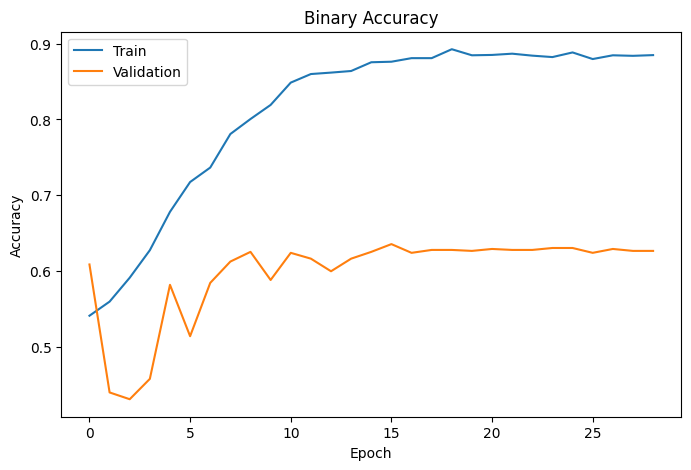

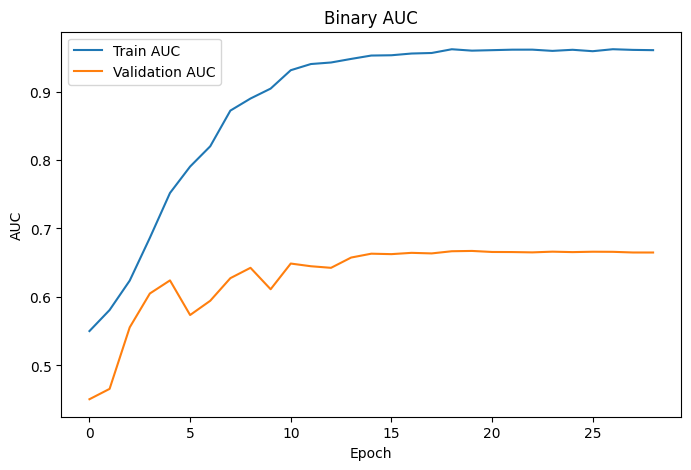


VALIDATION THRESHOLD SEARCH
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step
Best threshold: 0.55
Validation balanced accuracy: 0.6446
Validation macro F1: 0.636

STRICT UNSEEN-SUBJECT TEST
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step

FINAL BINARY RESULTS
Threshold         : 0.55
Accuracy          : 0.5988
Balanced Accuracy : 0.5995
Precision (HIGH)  : 0.4988
Recall (HIGH)     : 0.6029
F1 (HIGH)         : 0.5459
Macro F1          : 0.5933
ROC-AUC           : 0.6493

Classification Report:

              precision    recall  f1-score   support

      normal       0.69      0.60      0.64       510
        high       0.50      0.60      0.55       340

    accuracy                           0.60       850
   macro avg       0.60      0.60      0.59       850
weighted avg       0.62      0.60      0.60       850


Confusion Matrix:
[[304 206]
 [135 205]]


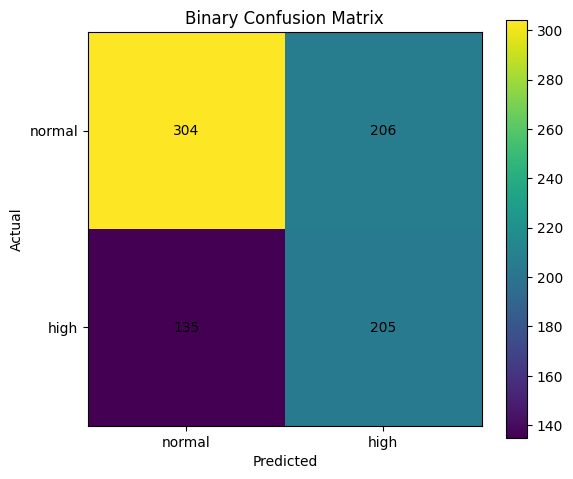


Keras model saved: /content/stress_binary_model/binary_normal_high.keras


In [6]:

# ============================================================
# 4. TRAIN BINARY NORMAL vs HIGH MODEL
# ============================================================

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    balanced_accuracy_score
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 45

MANIFEST = Path(
    "/content/stress_image_dataset_binary/"
    "image_manifest_binary.csv"
)

MODEL_DIR = Path(
    "/content/stress_binary_model"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 76)
print("BINARY EEG + GSR MODEL")
print("NORMAL vs HIGH")
print("=" * 76)

print("TensorFlow:", tf.__version__)
print(
    "GPU:",
    tf.config.list_physical_devices("GPU")
)

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "Enable T4 GPU before training."
    )

df = pd.read_csv(MANIFEST)

train_df = df[
    df["split"] == "train"
].reset_index(drop=True)

val_df = df[
    df["split"] == "validation"
].reset_index(drop=True)

test_df = df[
    df["split"] == "test"
].reset_index(drop=True)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain class distribution:")
print(
    train_df[
        "binary_label"
    ].value_counts()
)

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------

def read_image(path):
    image = tf.io.read_file(path)

    image = tf.io.decode_png(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        [
            IMG_SIZE,
            IMG_SIZE
        ]
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image

def load_pair(
    eeg_path,
    gsr_path,
    label
):
    return {
        "eeg_image":
            read_image(eeg_path),

        "gsr_image":
            read_image(gsr_path),
    }, tf.cast(
        label,
        tf.float32
    )

def make_dataset(
    frame,
    training=False
):
    dataset = (
        tf.data.Dataset
        .from_tensor_slices(
            (
                frame[
                    "eeg_image"
                ].astype(str).values,

                frame[
                    "gsr_image"
                ].astype(str).values,

                frame[
                    "binary_label_id"
                ].astype(np.float32).values
            )
        )
    )

    if training:
        dataset = dataset.shuffle(
            min(
                len(frame),
                5000
            ),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_pair,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

train_ds = make_dataset(
    train_df,
    training=True
)

val_ds = make_dataset(
    val_df,
    training=False
)

test_ds = make_dataset(
    test_df,
    training=False
)

# ------------------------------------------------------------
# CLASS WEIGHTS
# ------------------------------------------------------------

classes = np.array(
    [0, 1]
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df[
        "binary_label_id"
    ].values
)

class_weights = {
    0: float(weights[0]),
    1: float(weights[1]),
}

print(
    "\nClass weights:",
    class_weights
)

# ------------------------------------------------------------
# MODEL BLOCKS
# ------------------------------------------------------------

def se_block(
    x,
    ratio=8,
    name="se"
):
    channels = int(
        x.shape[-1]
    )

    s = tf.keras.layers.GlobalAveragePooling2D(
        name=name + "_gap"
    )(x)

    s = tf.keras.layers.Dense(
        max(
            channels // ratio,
            8
        ),
        activation="gelu",
        name=name + "_fc1"
    )(s)

    s = tf.keras.layers.Dense(
        channels,
        activation="sigmoid",
        name=name + "_fc2"
    )(s)

    s = tf.keras.layers.Reshape(
        (
            1,
            1,
            channels
        )
    )(s)

    return tf.keras.layers.Multiply(
        name=name + "_scale"
    )(
        [x, s]
    )

def residual_block(
    x,
    filters,
    stride,
    name
):
    shortcut = x

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False,
        name=name + "_conv1"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=name + "_bn1"
    )(x)

    x = tf.keras.layers.Activation(
        "gelu"
    )(x)

    x = tf.keras.layers.Conv2D(
        filters,
        3,
        padding="same",
        use_bias=False,
        name=name + "_conv2"
    )(x)

    x = tf.keras.layers.BatchNormalization(
        name=name + "_bn2"
    )(x)

    x = se_block(
        x,
        name=name + "_se"
    )

    if (
        stride != 1
        or
        int(
            shortcut.shape[-1]
        )
        != filters
    ):
        shortcut = tf.keras.layers.Conv2D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            name=name + "_proj"
        )(shortcut)

        shortcut = tf.keras.layers.BatchNormalization(
            name=name + "_proj_bn"
        )(shortcut)

    x = tf.keras.layers.Add()(
        [x, shortcut]
    )

    x = tf.keras.layers.Activation(
        "gelu"
    )(x)

    return x

def make_branch(
    input_tensor,
    prefix
):
    x = tf.keras.layers.Conv2D(
        32,
        5,
        strides=2,
        padding="same",
        use_bias=False,
        name=prefix + "_stem"
    )(input_tensor)

    x = tf.keras.layers.BatchNormalization()(
        x
    )

    x = tf.keras.layers.Activation(
        "gelu"
    )(x)

    x = residual_block(
        x,
        32,
        1,
        prefix + "_r1"
    )

    x = residual_block(
        x,
        64,
        2,
        prefix + "_r2"
    )

    x = residual_block(
        x,
        64,
        1,
        prefix + "_r3"
    )

    x = residual_block(
        x,
        128,
        2,
        prefix + "_r4"
    )

    x = residual_block(
        x,
        128,
        1,
        prefix + "_r5"
    )

    x = residual_block(
        x,
        192,
        2,
        prefix + "_r6"
    )

    x = tf.keras.layers.GlobalAveragePooling2D(
        name=prefix + "_gap"
    )(x)

    x = tf.keras.layers.Dense(
        192,
        activation="gelu",
        name=prefix + "_embedding"
    )(x)

    x = tf.keras.layers.Dropout(
        0.20
    )(x)

    return x

# ------------------------------------------------------------
# INPUTS
# ------------------------------------------------------------

eeg_input = tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),
    name="eeg_image"
)

gsr_input = tf.keras.Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    ),
    name="gsr_image"
)

# No flips.
eeg_aug = tf.keras.Sequential(
    [
        tf.keras.layers.RandomTranslation(
            0.01,
            0.015
        ),

        tf.keras.layers.RandomZoom(
            0.02,
            0.02
        ),
    ],
    name="eeg_aug"
)

gsr_aug = tf.keras.Sequential(
    [
        tf.keras.layers.RandomTranslation(
            0.01,
            0.015
        ),

        tf.keras.layers.RandomZoom(
            0.02,
            0.02
        ),
    ],
    name="gsr_aug"
)

eeg_feat = make_branch(
    eeg_aug(eeg_input),
    "eeg"
)

gsr_feat = make_branch(
    gsr_aug(gsr_input),
    "gsr"
)

# ------------------------------------------------------------
# GATED FUSION
# ------------------------------------------------------------

combined = tf.keras.layers.Concatenate(
    name="combined_features"
)(
    [
        eeg_feat,
        gsr_feat
    ]
)

gate = tf.keras.layers.Dense(
    2,
    activation="softmax",
    name="modality_gate"
)(
    combined
)

eeg_gate = tf.keras.layers.Lambda(
    lambda x: x[:, 0:1],
    name="eeg_gate"
)(
    gate
)

gsr_gate = tf.keras.layers.Lambda(
    lambda x: x[:, 1:2],
    name="gsr_gate"
)(
    gate
)

eeg_weighted = tf.keras.layers.Multiply()(
    [
        eeg_feat,
        eeg_gate
    ]
)

gsr_weighted = tf.keras.layers.Multiply()(
    [
        gsr_feat,
        gsr_gate
    ]
)

fusion = tf.keras.layers.Concatenate(
    name="gated_fusion"
)(
    [
        eeg_weighted,
        gsr_weighted
    ]
)

x = tf.keras.layers.Dense(
    256,
    activation="gelu"
)(
    fusion
)

x = tf.keras.layers.BatchNormalization()(
    x
)

x = tf.keras.layers.Dropout(
    0.30
)(
    x
)

x = tf.keras.layers.Dense(
    128,
    activation="gelu"
)(
    x
)

x = tf.keras.layers.Dropout(
    0.20
)(
    x
)

output = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="stress_probability"
)(
    x
)

model = tf.keras.Model(
    inputs=[
        eeg_input,
        gsr_input
    ],
    outputs=output,
    name="Binary_Normal_High_Model"
)

model.summary()

# ------------------------------------------------------------
# COMPILE
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss=tf.keras.losses.BinaryCrossentropy(
        label_smoothing=0.02
    ),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)

BEST_PATH = (
    MODEL_DIR
    /
    "best.weights.h5"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(BEST_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=9,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=3,
        factor=0.4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# ------------------------------------------------------------
# TRAINING CURVES
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Binary Accuracy")
plt.legend()
plt.show()

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["auc"],
    label="Train AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Binary AUC")
plt.legend()
plt.show()

# ------------------------------------------------------------
# VALIDATION THRESHOLD TUNING
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("VALIDATION THRESHOLD SEARCH")
print("=" * 76)

val_prob = model.predict(
    val_ds,
    verbose=1
).reshape(-1)

y_val = val_df[
    "binary_label_id"
].values.astype(np.int32)

thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

best_threshold = 0.5
best_balanced = -1
best_f1 = -1

for threshold in thresholds:
    pred = (
        val_prob >= threshold
    ).astype(np.int32)

    balanced = balanced_accuracy_score(
        y_val,
        pred
    )

    f1 = f1_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    # Prioritize balanced accuracy;
    # use macro-F1 as tie breaker.
    if (
        balanced > best_balanced
        or
        (
            np.isclose(
                balanced,
                best_balanced
            )
            and
            f1 > best_f1
        )
    ):
        best_balanced = balanced
        best_f1 = f1
        best_threshold = float(
            threshold
        )

print(
    "Best threshold:",
    round(
        best_threshold,
        2
    )
)

print(
    "Validation balanced accuracy:",
    round(
        best_balanced,
        4
    )
)

print(
    "Validation macro F1:",
    round(
        best_f1,
        4
    )
)

# ------------------------------------------------------------
# STRICT TEST
# ------------------------------------------------------------

print("\n" + "=" * 76)
print("STRICT UNSEEN-SUBJECT TEST")
print("=" * 76)

test_prob = model.predict(
    test_ds,
    verbose=1
).reshape(-1)

y_test = test_df[
    "binary_label_id"
].values.astype(np.int32)

test_pred = (
    test_prob
    >=
    best_threshold
).astype(np.int32)

accuracy = accuracy_score(
    y_test,
    test_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    test_pred
)

precision = precision_score(
    y_test,
    test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_pred,
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    test_pred,
    average="macro",
    zero_division=0
)

try:
    roc_auc = roc_auc_score(
        y_test,
        test_prob
    )
except Exception:
    roc_auc = np.nan

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=[0, 1]
)

print("\nFINAL BINARY RESULTS")
print(
    f"Threshold         : {best_threshold:.2f}"
)
print(
    f"Accuracy          : {accuracy:.4f}"
)
print(
    f"Balanced Accuracy : {balanced_accuracy:.4f}"
)
print(
    f"Precision (HIGH)  : {precision:.4f}"
)
print(
    f"Recall (HIGH)     : {recall:.4f}"
)
print(
    f"F1 (HIGH)         : {f1:.4f}"
)
print(
    f"Macro F1          : {macro_f1:.4f}"
)
print(
    f"ROC-AUC           : {roc_auc:.4f}"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "normal",
            "high"
        ],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.xticks(
    [0, 1],
    [
        "normal",
        "high"
    ]
)

plt.yticks(
    [0, 1],
    [
        "normal",
        "high"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SAVE MODEL + CONFIG
# ------------------------------------------------------------

KERAS_PATH = (
    MODEL_DIR
    /
    "binary_normal_high.keras"
)

model.save(
    KERAS_PATH
)

config = {
    "task":
        "NORMAL vs HIGH stress",

    "labels": {
        "0":
            "normal",

        "1":
            "high"
    },

    "mapping": {
        "low":
            "normal",

        "moderate":
            "normal",

        "high":
            "high"
    },

    "threshold":
        float(
            best_threshold
        ),

    "accuracy":
        float(
            accuracy
        ),

    "balanced_accuracy":
        float(
            balanced_accuracy
        ),

    "roc_auc":
        float(
            roc_auc
        ),

    "subject_independent_test":
        True
}

with open(
    MODEL_DIR
    /
    "model_config.json",
    "w"
) as f:
    json.dump(
        config,
        f,
        indent=4
    )

print(
    "\nKeras model saved:",
    KERAS_PATH
)

BINARY_MODEL = model
BINARY_THRESHOLD = best_threshold


In [7]:

# ============================================================
# 5. TFLITE EXPORT
# ============================================================

import os
import tensorflow as tf
from pathlib import Path

MODEL_DIR = Path(
    "/content/stress_binary_model"
)

KERAS_PATH = (
    MODEL_DIR
    /
    "binary_normal_high.keras"
)

TFLITE_PATH = (
    MODEL_DIR
    /
    "binary_normal_high.tflite"
)

model_export = tf.keras.models.load_model(
    KERAS_PATH,
    safe_mode=False
)

converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(
        model_export
    )
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

try:
    tflite_model = converter.convert()

except Exception as e:
    print(
        "Optimized conversion failed:"
    )
    print(e)

    print(
        "Retrying standard conversion..."
    )

    converter = (
        tf.lite.TFLiteConverter
        .from_keras_model(
            model_export
        )
    )

    tflite_model = converter.convert()

with open(
    TFLITE_PATH,
    "wb"
) as f:
    f.write(
        tflite_model
    )

size_mb = (
    os.path.getsize(
        TFLITE_PATH
    )
    /
    1024**2
)

print(
    "TFLite:",
    TFLITE_PATH
)

print(
    "Size MB:",
    round(
        size_mb,
        2
    )
)

print(
    "\nOFFLINE BINARY MODEL READY ✅"
)


Saved artifact at '/tmp/tmp4f24mpmw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='eeg_image'), TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='gsr_image')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135555777972176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777971984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777980624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777974672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777972752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777976208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777970640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777974864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555777981008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135555

In [8]:

# ============================================================
# 6. PACKAGE RESULTS
# ============================================================

import shutil
from pathlib import Path

MODEL_DIR = Path(
    "/content/stress_binary_model"
)

ZIP_PATH = shutil.make_archive(
    "/content/stress_binary_model_results",
    "zip",
    root_dir=MODEL_DIR
)

print(
    "Results ZIP:",
    ZIP_PATH
)

print(
    "Download it from the Colab Files panel."
)


Results ZIP: /content/stress_binary_model_results.zip
Download it from the Colab Files panel.
